In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("data/superstore_cleaned.csv")

df['order_date'] = pd.to_datetime(df['order_date'])
df

,row_id+o6g3a1:r6,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.940,1,28.2668,No,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,No,Online
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.980,2,67.2742,No,Cards
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.460,2,28.6150,No,Online
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.080,2,-5.2640,No,Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,907,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",213.136,4,12.1176,No,COD
5897,1297,CA-2020-115427,2020-12-30,2021-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",295.904,2,4.5188,1.0,Online
5898,5092,CA-2020-156720,2020-12-30,2021-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,388.024,3,-0.6048,No,Online
5899,909,CA-2020-143259,2020-12-30,2021-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,462.776,3,19.7910,No,COD


In [6]:
# Total Sales
total_sales = df['sales'].sum()

# Total Profit
total_profit = df['profit'].sum()

# Total Orders
total_orders = df['order_id'].nunique()

# Total Customers
total_customers = df['customer_id'].nunique()

total_sales, total_profit, total_orders, total_customers


(np.float64(1565804.3232), np.float64(175262.1059), 3003, 773)

In [8]:
# avg order value

aov = total_sales / total_orders
aov


np.float64(521.413361038961)

In [10]:
# profit margin

profit_margin = (total_profit / total_sales) * 100
profit_margin


np.float64(11.193103972392967)

In [12]:
customer_sales = (
    df.groupby('customer_name')['sales']
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)


customer_name
Caroline Jumper    11596.974
Karen Ferguson     10941.274
Seth Vernon        10751.148
Helen Wasserman    10074.934
Edward Hooks        9542.988
Bill Shonely        9199.780
Pete Kriz           8812.054
John Lee            8765.332
Adam Bellavance     8167.080
Jane Waco           7933.554
Name: sales, dtype: float64

In [14]:
# Repeat Customer Analysis

repeat_customers = df.groupby('customer_id')['order_id'].nunique()
repeat_customers.value_counts().head()


order_id
3    159
2    131
4    123
5    110
1     84
Name: count, dtype: int64

In [16]:
# Best Performing Products

top_products = (
    df.groupby('product_name')[['sales','profit']]
    .sum()
    .sort_values(by='sales', ascending=False)
)

top_products.head(10)


,sales,profit
product_name,,
"3D Systems Cube Printer, 2nd Generation, Magenta",14334.890,3717.9714
Canon imageCLASS 2200 Advanced Copier,14076.824,25199.9280
Hewlett Packard LaserJet 3310 Copier,13837.732,6407.8932
GBC DocuBind TL300 Electric Binding System,12890.258,2753.7593
GBC DocuBind P400 Electric Binding System,12577.108,762.1544
Samsung Galaxy Mega 6.3,12370.708,1696.7596
Martin Yale Chadless Opener Electric Letter Opener,12268.902,-1232.5588
HON 5400 Series Task Chairs for Big and Tall,11887.562,70.0980
Global Troy Executive Leather Low-Back Tilter,10217.894,776.5190


In [18]:
# Shipping Mode Efficiency

shipping_analysis = df.groupby('ship_mode')[['sales','profit']].mean()
shipping_analysis


,sales,profit
ship_mode,,
First Class,253.322961,31.021759
Same Day,278.949131,25.607047
Second Class,274.200579,32.202290
Standard Class,264.387435,28.909704


returns
1.0    53.794241
No     28.468678
Name: profit, dtype: float64


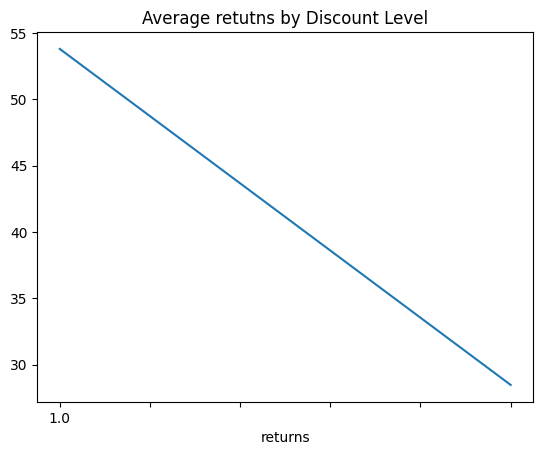

In [22]:
# Discount Impact Analysis

discount_profit = df.groupby('returns')['profit'].mean()
print(discount_profit)


discount_profit.plot(title="Average retutns by Discount Level")
plt.show()
